#  Import libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit openpyxl -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import joblib
from sklearn.pipeline import Pipeline

### Load your dataset

In [16]:
df = pd.read_csv('UCI_Credit_Card.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Rename columns to business names

In [17]:
df.columns = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default_payment_next_month'
]
print("Columns renamed!")
df.head()

Columns renamed!


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


###  Data quality check

In [18]:
print("Dataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget distribution:")
print(df['default_payment_next_month'].value_counts(normalize=True))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2        

##  Feature engineering

In [19]:
# Bill and payment summaries
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
repay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['AVG_BILL'] = df[bill_cols].mean(axis=1)
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['AVG_PAY'] = df[pay_cols].mean(axis=1)
df['TOTAL_PAY'] = df[pay_cols].sum(axis=1)
df['PAY_TO_BILL_RATIO'] = df['TOTAL_PAY'] / (df['TOTAL_BILL'] + 1)
df['AVG_REPAY_STATUS'] = df[repay_cols].mean(axis=1)

print(df[['AVG_BILL', 'PAY_TO_BILL_RATIO', 'AVG_REPAY_STATUS']].head())

       AVG_BILL  PAY_TO_BILL_RATIO  AVG_REPAY_STATUS
0   1284.000000           0.089422         -0.333333
1   2846.166667           0.292774          0.500000
2  16942.166667           0.108387          0.000000
3  38555.666667           0.036259          0.000000
4  18223.166667           0.540049         -0.333333


## EDA - Default rate

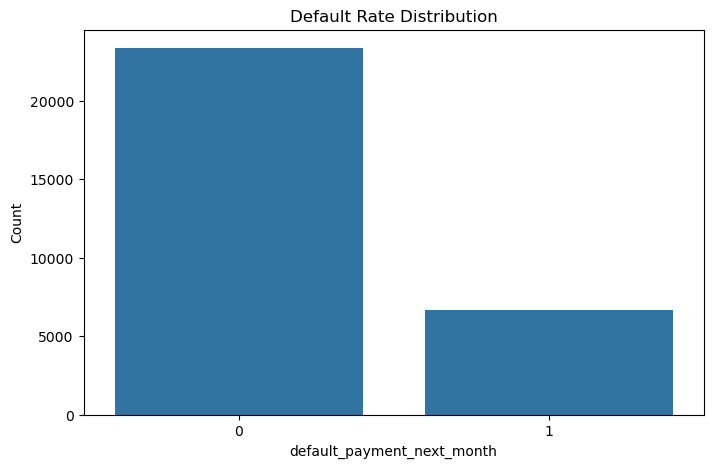

Default rate: 0.2212


In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='default_payment_next_month')
plt.title('Default Rate Distribution')
plt.ylabel('Count')
plt.show()
print("Default rate:", df['default_payment_next_month'].mean())

## EDA - Credit limit vs default

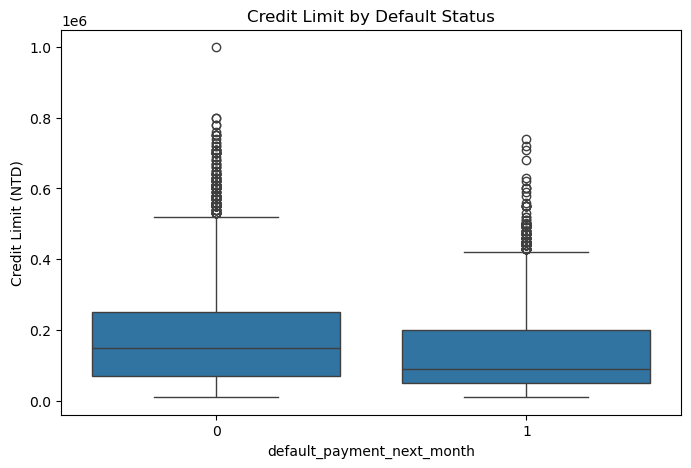

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='default_payment_next_month', y='LIMIT_BAL')
plt.title('Credit Limit by Default Status')
plt.ylabel('Credit Limit (NTD)')
plt.show()

## EDA - Repayment status (key predictor)

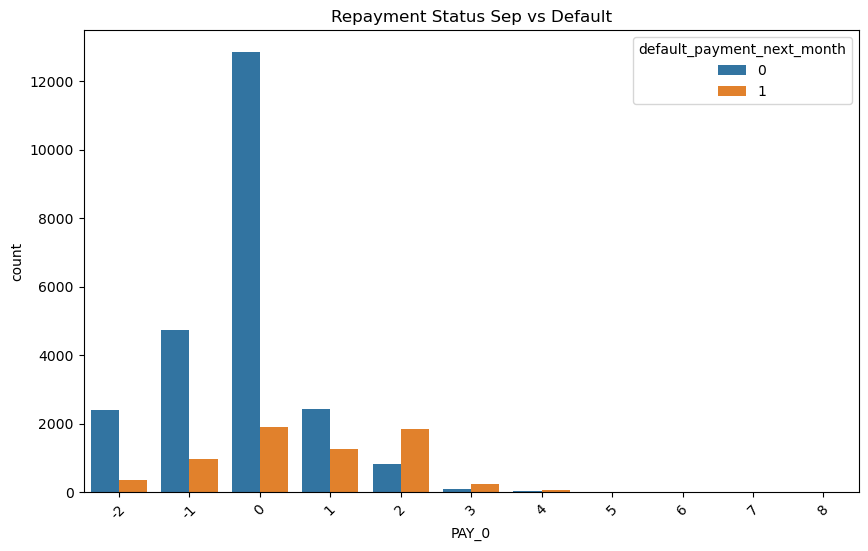

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PAY_0', hue='default_payment_next_month')
plt.title('Repayment Status Sep vs Default')
plt.xticks(rotation=45)
plt.show()

##  Prepare data for modeling

In [23]:
target = 'default_payment_next_month'
feature_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE'] + \
               repay_cols + bill_cols + pay_cols + \
               ['AVG_BILL', 'TOTAL_BILL', 'AVG_PAY', 'TOTAL_PAY', 'PAY_TO_BILL_RATIO', 'AVG_REPAY_STATUS']

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (24000, 29)
Test set: (6000, 29)


## Baseline model - Logistic Regression

In [24]:
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

log_pipeline.fit(X_train, y_train)
log_preds = log_pipeline.predict(X_test)
log_probs = log_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.7081617030348467


## Advanced model - Random Forest

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.50      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7748407492834705


## ROC Curves comparison

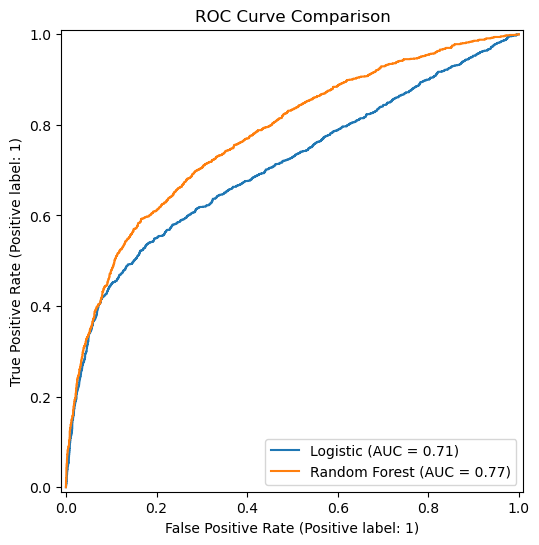

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, log_probs, name="Logistic", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name="Random Forest", ax=ax)
plt.title("ROC Curve Comparison")
plt.show()

## Feature importance (Random Forest)

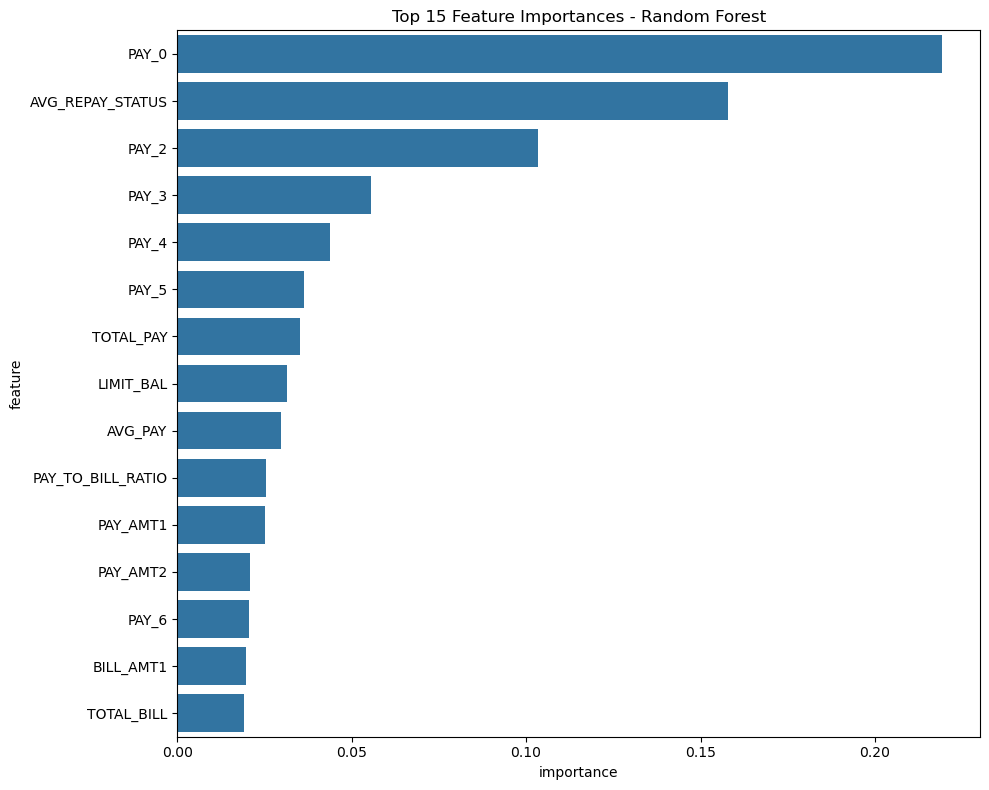

              feature  importance
5               PAY_0    0.219166
28   AVG_REPAY_STATUS    0.157934
6               PAY_2    0.103320
7               PAY_3    0.055489
8               PAY_4    0.043885
9               PAY_5    0.036226
26          TOTAL_PAY    0.035145
0           LIMIT_BAL    0.031513
25            AVG_PAY    0.029783
27  PAY_TO_BILL_RATIO    0.025563
17           PAY_AMT1    0.025055
18           PAY_AMT2    0.020959
10              PAY_6    0.020587
11          BILL_AMT1    0.019596
24         TOTAL_BILL    0.019099


In [27]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()
print(importance_df)

## Confusion Matrix (Random Forest)

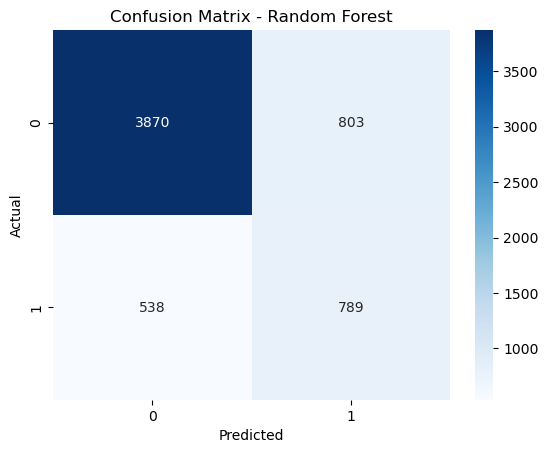

In [28]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Save the best model

In [30]:
joblib.dump(rf_model, 'loan_default_model.pkl')
print("Model saved as 'loan_default_model.pkl'")

Model saved as 'loan_default_model.pkl'


## Insights

In [29]:
print("=== KEY INSIGHTS ===")
print("1. Default rate:", round(df['default_payment_next_month'].mean()*100, 1), "%")
print("2. Repayment status variables are top predictors (makes business sense)")
print("3. Higher credit limits correlate with lower defaults")
print("4. Random Forest outperforms logistic regression (AUC:", round(roc_auc_score(y_test, rf_probs), 3), ")")
print("5. In lending, focus on recall for defaults to minimize risk exposure")

=== KEY INSIGHTS ===
1. Default rate: 22.1 %
2. Repayment status variables are top predictors (makes business sense)
3. Higher credit limits correlate with lower defaults
4. Random Forest outperforms logistic regression (AUC: 0.775 )
5. In lending, focus on recall for defaults to minimize risk exposure
